# 05 — Backtester

Simulates the cross-sectional momentum strategy over the full 30-day history.

**Design principles:**
- Bar-based simulation (not event-driven) — simple and auditable
- Fees applied per actual turnover, not per rebalance
- Taker (0.10%) for market orders, maker (0.05%) for limit orders
- No lookahead bias: signal computed on bars *before* the execution bar
- Survivorship bias: not an issue — all coins present for full 30 days

**Outputs:**
- Equity curve, drawdown curve, rolling Sharpe
- Full metrics: Return, Sharpe, Sortino, Calmar, Max DD, Hit Rate
- Per-trade breakdown saved to DuckDB backtest_trades table
- Sensitivity table: fee regime × rebalance frequency

In [13]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import uuid
from datetime import datetime, timezone, timedelta
from signals.momentum import MomentumSignal, MomentumConfig, load_universe_from_csv

DB_PATH  = '../data/ohlcv_1m.duckdb'
RES_DB   = '../data/research.duckdb'   # for writing backtest results
con      = duckdb.connect(DB_PATH, read_only=True)
res_con  = duckdb.connect(RES_DB)
universe = [
    'BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD', 'DOGE-USD',
    'BNB-USD', 'PEPE-USD', 'SUI-USD', 'ADA-USD', 'TRX-USD',
    'TAO-USD', 'LINK-USD', 'AVAX-USD', 'NEAR-USD', 'TRUMP-USD',
    'LTC-USD', 'ASTER-USD', 'WLFI-USD', 'UNI-USD', 'ZEC-USD',
]

# ── Fee assumptions ───────────────────────────────────────────────
FEE_TAKER = 0.001   # 0.10% market order
FEE_MAKER = 0.0005  # 0.05% limit order

INITIAL_CAPITAL = 1_000_000   # $1M mock portfolio

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.grid':True,'grid.alpha':0.3,'font.size':10})
print(f'Universe : {len(universe)} coins')
print(f'Capital  : ${INITIAL_CAPITAL:,.0f}')

Universe : 20 coins
Capital  : $1,000,000


## 1. Load Hourly Price Matrix

Build a single price pivot (timestamps × symbols) — the backbone of the simulation.

In [15]:
# Resample 1m → 1h for all coins in one query
price_df = con.execute("""
    SELECT
        DATE_TRUNC('hour', ts)          AS ts_hour,
        symbol,
        LAST(close ORDER BY ts)         AS close,
        SUM(volume)                     AS volume
    FROM ohlcv
    WHERE interval = '1m'
    GROUP BY DATE_TRUNC('hour', ts), symbol
    ORDER BY ts_hour, symbol
""").df()

price_df['ts_hour'] = pd.to_datetime(price_df['ts_hour'], utc=True)

# Pivot to wide format
prices = price_df.pivot_table(index='ts_hour', columns='symbol', values='close').sort_index()
volumes = price_df.pivot_table(index='ts_hour', columns='symbol', values='volume').sort_index()

# Keep only universe coins
prices  = prices[[c for c in universe if c in prices.columns]]
volumes = volumes[[c for c in universe if c in volumes.columns]]

print(f'Price matrix : {prices.shape}  (hours × coins)')
print(f'Date range   : {prices.index[0]}  →  {prices.index[-1]}')
print(f'NaN count    : {prices.isna().sum().sum()} cells')

Price matrix : (721, 20)  (hours × coins)
Date range   : 2026-02-16 07:00:00+00:00  →  2026-03-18 07:00:00+00:00
NaN count    : 0 cells


## 2. Generate Signal Weight Matrix

Run the full signal replay over all timestamps.
This uses `compute_batch()` which respects the 4h rebalance frequency and turnover gate.

In [16]:
cfg = MomentumConfig()   # all defaults: 6h lookback, 4h rebalance, score threshold 0.60
signal = MomentumSignal(con=con, universe=universe, cfg=cfg)

# Warmup: skip first N hours so signal has enough history
warmup_h   = max(cfg.lookback_primary, cfg.vol_lookback) + 10
timestamps = prices.index[warmup_h:].tolist()

print(f'Signal params  : lookback={cfg.lookback_primary}h, rebal={cfg.rebalance_freq_h}h, score_thresh={cfg.min_score_threshold}')
print(f'Warmup bars    : {warmup_h}h')
print(f'Simulation timestamps : {len(timestamps)}')
print(f'Running compute_batch — may take 1-3 min...')

weights_df = signal.compute_batch(timestamps)
weights_df = weights_df.reindex(columns=prices.columns, fill_value=0.0)

print(f'Weight matrix  : {weights_df.shape}')
print(f'Rebalance events (rows with any change): {(weights_df.diff().abs().sum(axis=1) > 0.001).sum()}')

Signal params  : lookback=6h, rebal=4h, score_thresh=0.6
Warmup bars    : 24h
Simulation timestamps : 697
Running compute_batch — may take 1-3 min...
Weight matrix  : (697, 20)
Rebalance events (rows with any change): 144


## 3. Portfolio Simulation

**Key design decisions:**
- Signal at bar `t` → execution at bar `t+1` open (no lookahead)
- Fees charged on `|Δweight|` per symbol per rebalance
- We simulate TWO fee regimes: taker-only vs maker (limit orders)
- Cash = 1 - sum(weights), earns 0% (conservative)

In [17]:
def simulate_portfolio(
    weights_df: pd.DataFrame,
    prices: pd.DataFrame,
    fee_rate: float = FEE_TAKER,
    initial_capital: float = INITIAL_CAPITAL,
) -> pd.DataFrame:
    """
    Vectorised portfolio simulation.

    Parameters
    ----------
    weights_df : pd.DataFrame
        Target weights at each timestamp (index=ts, cols=symbols).
        Signal at t is executed at t+1.
    prices : pd.DataFrame
        Hourly close prices (index=ts, cols=symbols).
    fee_rate : float
        Per-side fee rate (0.001 = 0.1%).
    initial_capital : float
        Starting portfolio value in USD.

    Returns
    -------
    pd.DataFrame with columns:
        portfolio_value, gross_return, net_return, fee_paid,
        turnover, n_positions, cash_pct
    """
    # Align weights to prices index, shift by 1 (execute next bar)
    w = weights_df.reindex(prices.index).fillna(method='ffill').fillna(0.0)
    w_exec = w.shift(1).fillna(0.0)   # weights applied at t+1

    # Hourly log returns for each coin
    log_ret = np.log(prices / prices.shift(1)).fillna(0.0)

    # Gross portfolio return per bar
    # = sum(weight_i × return_i) for each bar
    gross_ret = (w_exec * log_ret).sum(axis=1)

    # Turnover per bar = sum(|w_t - w_{t-1}|) / 2
    weight_change = w_exec.diff().abs()
    turnover = weight_change.sum(axis=1) / 2

    # Fee per bar = turnover × fee_rate × 2 (buy + sell sides)
    fee_cost = turnover * fee_rate * 2

    # Net return
    net_ret = gross_ret - fee_cost

    # Portfolio value
    portfolio_value = initial_capital * np.exp(net_ret.cumsum())

    results = pd.DataFrame({
        'portfolio_value' : portfolio_value,
        'gross_ret'       : gross_ret,
        'net_ret'         : net_ret,
        'fee_paid'        : fee_cost * portfolio_value,
        'turnover'        : turnover,
        'n_positions'     : (w_exec > 0).sum(axis=1),
        'cash_pct'        : 1 - w_exec.sum(axis=1),
    }, index=prices.index)

    return results


# Run both fee scenarios
sim_taker = simulate_portfolio(weights_df, prices, fee_rate=FEE_TAKER)
sim_maker = simulate_portfolio(weights_df, prices, fee_rate=FEE_MAKER)

# BTC buy-and-hold benchmark
btc_ret   = np.log(prices['BTC-USD'] / prices['BTC-USD'].iloc[0])
btc_value = INITIAL_CAPITAL * np.exp(btc_ret)

print('Simulation complete.')
print(f'Taker final value : ${sim_taker["portfolio_value"].iloc[-1]:,.0f}')
print(f'Maker final value : ${sim_maker["portfolio_value"].iloc[-1]:,.0f}')
print(f'BTC B&H final     : ${btc_value.iloc[-1]:,.0f}')

Simulation complete.
Taker final value : $866,689
Maker final value : $950,272
BTC B&H final     : $1,077,747


## 4. Performance Metrics

In [18]:
def compute_metrics(sim: pd.DataFrame, label: str, initial: float = INITIAL_CAPITAL) -> dict:
    """Compute full suite of risk-adjusted performance metrics."""
    ret = sim['net_ret'].dropna()
    pv  = sim['portfolio_value'].dropna()

    # Annualisation factor: 24h × 365 days = 8760 hourly bars/year
    ANN = 8760

    total_return   = (pv.iloc[-1] / initial - 1) * 100
    ann_return     = ret.mean() * ANN * 100
    ann_vol        = ret.std()  * np.sqrt(ANN) * 100
    sharpe         = (ret.mean() / ret.std() * np.sqrt(ANN)) if ret.std() > 0 else 0

    # Sortino: downside deviation only
    downside = ret[ret < 0]
    sortino  = (ret.mean() / downside.std() * np.sqrt(ANN)) if len(downside) > 0 else 0

    # Max drawdown
    rolling_max = pv.cummax()
    drawdown    = (pv - rolling_max) / rolling_max
    max_dd      = drawdown.min() * 100

    # Calmar = annualised return / |max drawdown|
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0

    # Hit rate (% of bars with positive net return, excluding flat bars)
    active_bars = ret[ret != 0]
    hit_rate    = (active_bars > 0).mean() * 100 if len(active_bars) > 0 else 0

    # Profit factor
    wins   = active_bars[active_bars > 0].sum()
    losses = active_bars[active_bars < 0].abs().sum()
    pf     = wins / losses if losses > 0 else np.inf

    # Total fees paid
    total_fees = sim['fee_paid'].sum()
    avg_turnover = sim['turnover'][sim['turnover'] > 0].mean() * 100

    return {
        'label'          : label,
        'total_return_%' : round(total_return, 2),
        'ann_return_%'   : round(ann_return, 2),
        'ann_vol_%'      : round(ann_vol, 2),
        'sharpe'         : round(sharpe, 3),
        'sortino'        : round(sortino, 3),
        'max_dd_%'       : round(max_dd, 2),
        'calmar'         : round(calmar, 3),
        'hit_rate_%'     : round(hit_rate, 2),
        'profit_factor'  : round(pf, 3),
        'total_fees_$'   : round(total_fees, 0),
        'avg_turnover_%' : round(avg_turnover, 2),
    }


# BTC benchmark metrics
btc_sim = pd.DataFrame({'net_ret': np.log(prices['BTC-USD']/prices['BTC-USD'].shift(1)).fillna(0),
                        'portfolio_value': btc_value,
                        'fee_paid': 0, 'turnover': 0})

metrics = pd.DataFrame([
    compute_metrics(sim_taker, 'Strategy (Taker 0.1%)'),
    compute_metrics(sim_maker, 'Strategy (Maker 0.05%)'),
    compute_metrics(btc_sim,   'BTC Buy & Hold'),
])

print('\n' + '='*65)
print('BACKTEST PERFORMANCE SUMMARY')
print('='*65)
display(metrics.set_index('label').T)


BACKTEST PERFORMANCE SUMMARY


label,Strategy (Taker 0.1%),Strategy (Maker 0.05%),BTC Buy & Hold
total_return_%,-13.330,-4.970,7.770
ann_return_%,-173.830,-61.970,90.970
ann_vol_%,60.240,60.180,53.690
sharpe,-2.886,-1.030,1.694
sortino,-4.367,-1.557,2.371
max_dd_%,-17.810,-14.110,-10.480
calmar,-9.760,-4.392,8.681
hit_rate_%,46.700,47.270,51.110
profit_factor,0.914,0.968,1.054
total_fees_$,166707.000,87242.000,0.000


## 5. Equity Curve & Drawdown

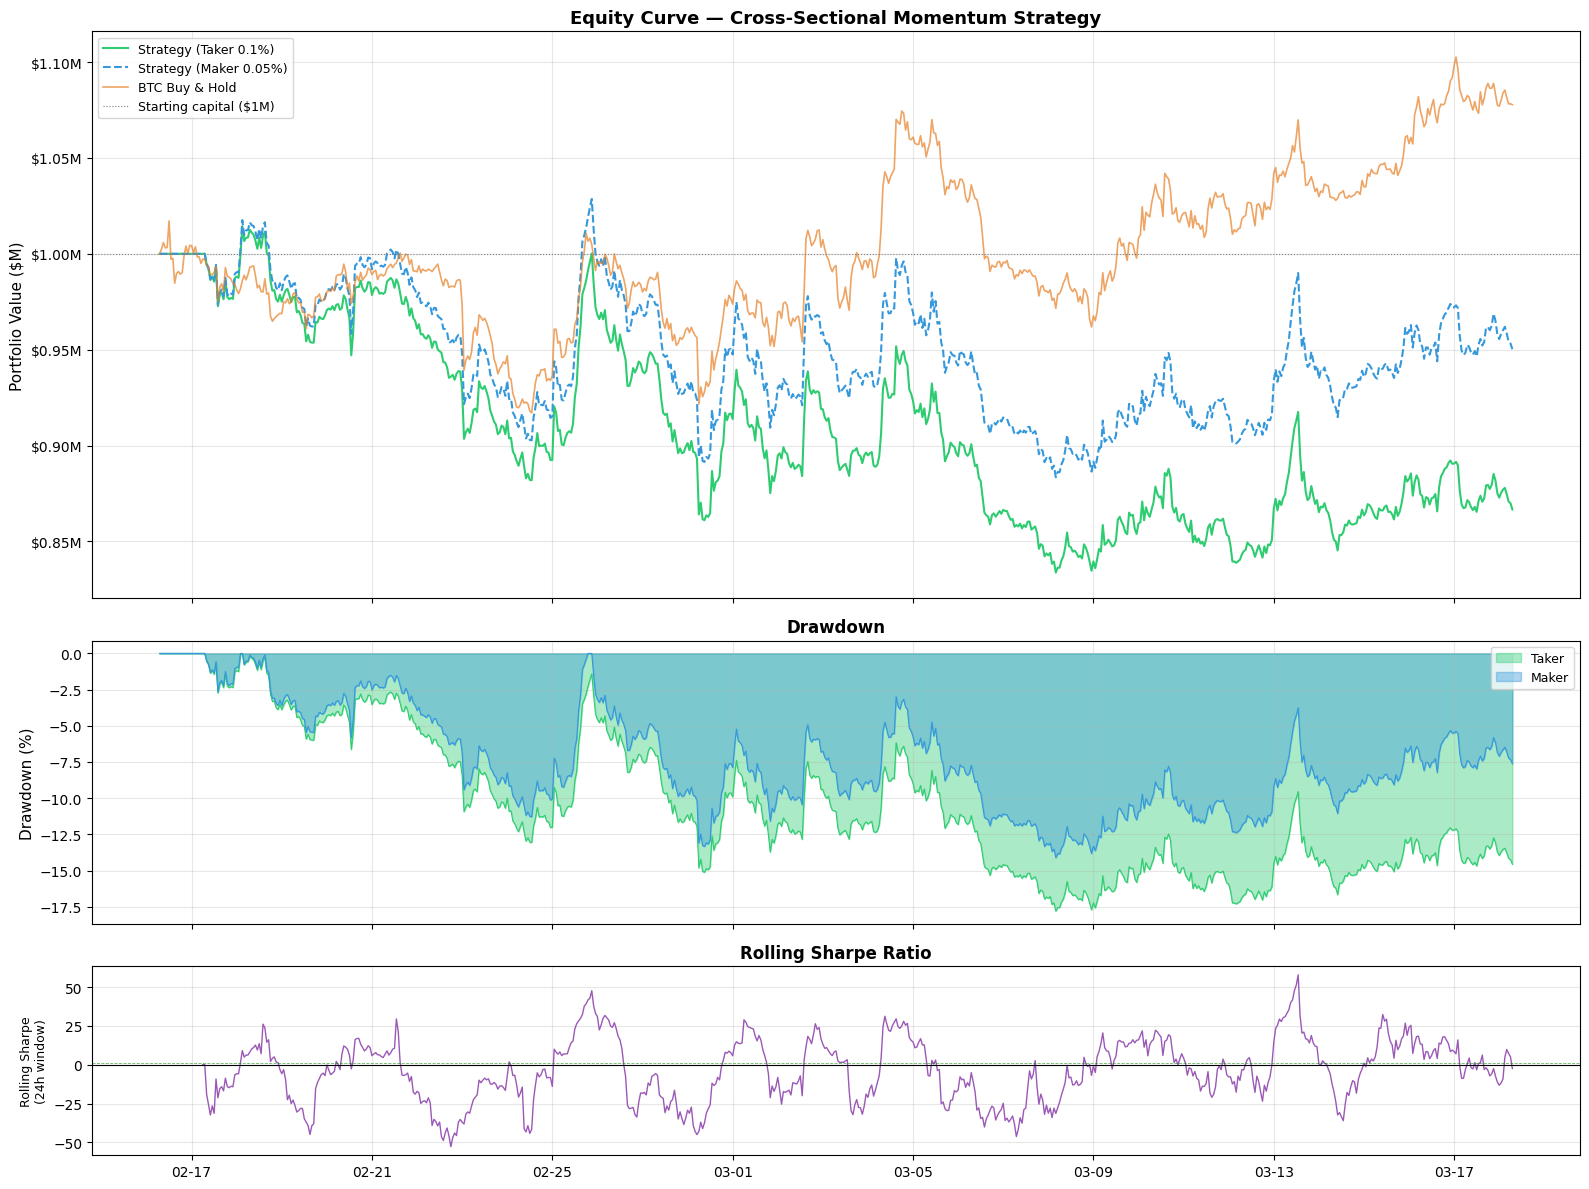

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.5, 1]})

# ── Equity curve ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(sim_taker.index, sim_taker['portfolio_value'] / 1e6,
        color='#2ecc71', linewidth=1.5, label='Strategy (Taker 0.1%)')
ax.plot(sim_maker.index, sim_maker['portfolio_value'] / 1e6,
        color='#3498db', linewidth=1.5, label='Strategy (Maker 0.05%)', linestyle='--')
ax.plot(btc_value.index, btc_value / 1e6,
        color='#e67e22', linewidth=1.2, label='BTC Buy & Hold', alpha=0.7)
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':', label='Starting capital ($1M)')
ax.set_ylabel('Portfolio Value ($M)', fontsize=11)
ax.set_title('Equity Curve — Cross-Sectional Momentum Strategy', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}M'))

# ── Drawdown ──────────────────────────────────────────────────────
ax2 = axes[1]
for sim, color, label in [
    (sim_taker, '#2ecc71', 'Taker'),
    (sim_maker, '#3498db', 'Maker'),
]:
    pv  = sim['portfolio_value']
    dd  = (pv - pv.cummax()) / pv.cummax() * 100
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.4, color=color, label=label)
    ax2.plot(dd.index, dd.values, color=color, linewidth=0.8)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.set_title('Drawdown', fontweight='bold')
ax2.legend(fontsize=9)

# ── Rolling 24h Sharpe ────────────────────────────────────────────
ax3 = axes[2]
roll_sharpe = sim_maker['net_ret'].rolling(24).apply(
    lambda x: x.mean() / x.std() * np.sqrt(8760) if x.std() > 0 else 0
)
ax3.plot(roll_sharpe.index, roll_sharpe.values, color='#9b59b6', linewidth=1.0)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.axhline(1, color='green', linewidth=0.6, linestyle='--', alpha=0.6)
ax3.set_ylabel('Rolling Sharpe\n(24h window)', fontsize=9)
ax3.set_title('Rolling Sharpe Ratio', fontweight='bold')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.tight_layout()
plt.savefig('../data/backtest_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Return Distribution

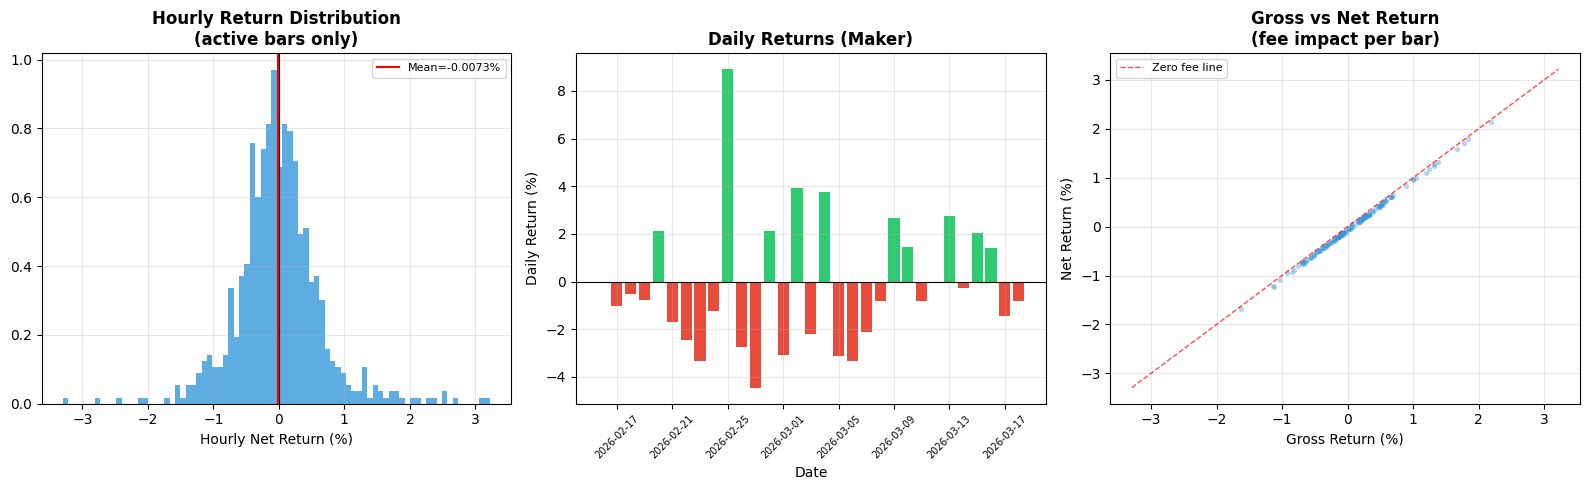

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Hourly return distribution
ret = sim_maker['net_ret'].dropna()
ret_active = ret[ret != 0]

axes[0].hist(ret_active * 100, bins=80, color='#3498db', alpha=0.8, edgecolor='none', density=True)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(ret_active.mean()*100, color='red', linewidth=1.5,
                label=f'Mean={ret_active.mean()*100:.4f}%')
axes[0].set_xlabel('Hourly Net Return (%)')
axes[0].set_title('Hourly Return Distribution\n(active bars only)', fontweight='bold')
axes[0].legend(fontsize=8)

# Daily return distribution
daily_ret = sim_maker['net_ret'].resample('1D').sum().dropna()
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in daily_ret]
axes[1].bar(daily_ret.index, daily_ret.values * 100, color=colors, width=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_title('Daily Returns (Maker)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)

# Gross vs net return scatter (fee impact)
has_activity = sim_maker['turnover'] > 0.001
axes[2].scatter(
    sim_maker.loc[has_activity, 'gross_ret'] * 100,
    sim_maker.loc[has_activity, 'net_ret'] * 100,
    alpha=0.3, s=8, color='#3498db'
)
lims = [
    min(sim_maker['gross_ret'].min(), sim_maker['net_ret'].min()) * 100,
    max(sim_maker['gross_ret'].max(), sim_maker['net_ret'].max()) * 100,
]
axes[2].plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='Zero fee line')
axes[2].set_xlabel('Gross Return (%)')
axes[2].set_ylabel('Net Return (%)')
axes[2].set_title('Gross vs Net Return\n(fee impact per bar)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/backtest_return_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Fee Sensitivity Table

How much does strategy performance change across fee rates and rebalance frequencies?

In [21]:
fee_sensitivity = []
for fee_rate, fee_label in [(0.0, 'Zero fees'), (FEE_MAKER, 'Maker 0.05%'),
                             (FEE_TAKER, 'Taker 0.10%'), (0.002, 'High 0.20%')]:
    sim = simulate_portfolio(weights_df, prices, fee_rate=fee_rate)
    m   = compute_metrics(sim, fee_label)
    fee_sensitivity.append(m)

fee_df = pd.DataFrame(fee_sensitivity).set_index('label')
print('Fee sensitivity:')
display(fee_df[['total_return_%','ann_return_%','sharpe','sortino','max_dd_%','calmar']].T)

Fee sensitivity:


label,Zero fees,Maker 0.05%,Taker 0.10%,High 0.20%
total_return_%,4.190,-4.970,-13.330,-27.910
ann_return_%,49.890,-61.970,-173.830,-397.550
sharpe,0.828,-1.030,-2.886,-6.553
sortino,1.251,-1.557,-4.367,-9.904
max_dd_%,-12.750,-14.110,-17.810,-28.490
calmar,3.912,-4.392,-9.760,-13.953


## 8. Rebalance Frequency Sensitivity

Does rebalancing every 4h beat every 1h or every 8h after fees?

In [22]:
rebal_sensitivity = []
for freq_h in [1, 2, 4, 6, 8, 12]:
    cfg_r  = MomentumConfig(rebalance_freq_h=freq_h)
    sig_r  = MomentumSignal(con=con, universe=universe, cfg=cfg_r)
    wdf_r  = sig_r.compute_batch(timestamps)
    wdf_r  = wdf_r.reindex(columns=prices.columns, fill_value=0.0)
    sim_r  = simulate_portfolio(wdf_r, prices, fee_rate=FEE_MAKER)
    m      = compute_metrics(sim_r, f'Rebal {freq_h}h (Maker)')
    m['rebal_freq_h'] = freq_h
    rebal_sensitivity.append(m)
    print(f'  {freq_h}h: Sharpe={m["sharpe"]:.3f}  Return={m["total_return_%"]:.2f}%  MaxDD={m["max_dd_%"]:.2f}%')

rebal_df = pd.DataFrame(rebal_sensitivity).set_index('label')
print('\nRebalance frequency sensitivity (Maker fees):')
display(rebal_df[['total_return_%','sharpe','sortino','max_dd_%','calmar','avg_turnover_%']].T)

  1h: Sharpe=-3.666  Return=-16.42%  MaxDD=-19.22%
  2h: Sharpe=-3.377  Return=-15.20%  MaxDD=-20.07%
  4h: Sharpe=-1.030  Return=-4.97%  MaxDD=-14.11%
  6h: Sharpe=-1.266  Return=-6.12%  MaxDD=-18.18%
  8h: Sharpe=-0.245  Return=-1.21%  MaxDD=-16.11%
  12h: Sharpe=-0.741  Return=-3.65%  MaxDD=-21.09%

Rebalance frequency sensitivity (Maker fees):


label,Rebal 1h (Maker),Rebal 2h (Maker),Rebal 4h (Maker),Rebal 6h (Maker),Rebal 8h (Maker),Rebal 12h (Maker)
total_return_%,-16.420,-15.200,-4.970,-6.120,-1.210,-3.650
sharpe,-3.666,-3.377,-1.030,-1.266,-0.245,-0.741
sortino,-5.297,-4.978,-1.557,-1.905,-0.344,-1.022
max_dd_%,-19.220,-20.070,-14.110,-18.180,-16.110,-21.090
calmar,-11.338,-9.981,-4.392,-4.219,-0.918,-2.142
avg_turnover_%,39.710,49.630,63.490,74.130,74.920,73.580


## 9. Walk-Forward Validation

Split data into train (first 20 days) and test (last 10 days).
If performance holds in-sample and out-of-sample, the signal is robust.

In [23]:
split_date = prices.index[0] + timedelta(days=20)

prices_train = prices[prices.index < split_date]
prices_test  = prices[prices.index >= split_date]
weights_train = weights_df[weights_df.index < split_date]
weights_test  = weights_df[weights_df.index >= split_date]

sim_train = simulate_portfolio(weights_train, prices_train, fee_rate=FEE_MAKER)
sim_test  = simulate_portfolio(weights_test,  prices_test,  fee_rate=FEE_MAKER)

# BTC split
btc_train = pd.DataFrame({
    'net_ret': np.log(prices_train['BTC-USD']/prices_train['BTC-USD'].shift(1)).fillna(0),
    'portfolio_value': INITIAL_CAPITAL * np.exp(np.log(prices_train['BTC-USD']/prices_train['BTC-USD'].iloc[0])),
    'fee_paid': 0, 'turnover': 0
})
btc_test = pd.DataFrame({
    'net_ret': np.log(prices_test['BTC-USD']/prices_test['BTC-USD'].shift(1)).fillna(0),
    'portfolio_value': INITIAL_CAPITAL * np.exp(np.log(prices_test['BTC-USD']/prices_test['BTC-USD'].iloc[0])),
    'fee_paid': 0, 'turnover': 0
})

wf_metrics = pd.DataFrame([
    compute_metrics(sim_train,  'Strategy — Train (Day 1-20)', sim_train['portfolio_value'].iloc[0]),
    compute_metrics(sim_test,   'Strategy — Test  (Day 21-30)', sim_test['portfolio_value'].iloc[0]),
    compute_metrics(btc_train,  'BTC — Train', btc_train['portfolio_value'].iloc[0]),
    compute_metrics(btc_test,   'BTC — Test',  btc_test['portfolio_value'].iloc[0]),
]).set_index('label')

print('Walk-Forward Validation:')
display(wf_metrics[['total_return_%','sharpe','sortino','max_dd_%','calmar']].T)

Walk-Forward Validation:


label,Strategy — Train (Day 1-20),Strategy — Test (Day 21-30),BTC — Train,BTC — Test
total_return_%,-11.390,6.690,-2.080,9.800
sharpe,-3.502,4.357,-0.679,7.153
sortino,-5.336,6.486,-0.903,12.186
max_dd_%,-14.110,-7.590,-9.840,-3.920
calmar,-15.635,30.994,-3.899,86.683


In [24]:
# Paste into a new cell in 05_backtest.ipynb

# What did the strategy actually hold vs what performed best?
# Check: did we hold the coins that went DOWN while missing the ones that went UP?

# Best performing coins over the full 30 days
total_returns = (prices.iloc[-1] / prices.iloc[0] - 1).sort_values(ascending=False)
print("Top 10 best performing coins (30-day return):")
print(total_returns.head(10).mul(100).round(2).to_string())
print()
print("Bottom 10 worst performing coins:")
print(total_returns.tail(10).mul(100).round(2).to_string())
print()

# How often did we hold the top performers?
top10_coins = total_returns.head(10).index.tolist()
avg_weight_top10 = weights_df[top10_coins].mean().sort_values(ascending=False)
print("Avg weight in top-10 performing coins:")
print(avg_weight_top10.mul(100).round(2).to_string())
print()

# Overall avg weight per coin
avg_weights_all = weights_df.mean().sort_values(ascending=False)
print("Overall avg weight per coin (top 15):")
print(avg_weights_all.head(15).mul(100).round(2).to_string())

Top 10 best performing coins (30-day return):
symbol
TAO-USD     49.81
NEAR-USD    37.74
ETH-USD     17.69
LINK-USD    11.99
UNI-USD     11.51
SOL-USD     10.65
AVAX-USD    10.58
BNB-USD      9.71
BTC-USD      7.77
TRX-USD      7.76

Bottom 10 worst performing coins:
symbol
SUI-USD       6.86
LTC-USD       6.79
TRUMP-USD     4.95
ASTER-USD     4.50
XRP-USD       4.00
ADA-USD       2.71
WLFI-USD      1.90
DOGE-USD     -2.24
ZEC-USD      -2.37
PEPE-USD    -17.90

Avg weight in top-10 performing coins:
symbol
TRX-USD     7.89
ETH-USD     6.25
TAO-USD     6.08
NEAR-USD    5.22
BNB-USD     5.19
SOL-USD     5.15
BTC-USD     4.92
UNI-USD     4.79
LINK-USD    4.67
AVAX-USD    3.89

Overall avg weight per coin (top 15):
symbol
TRX-USD      7.89
ETH-USD      6.25
TAO-USD      6.08
SUI-USD      5.55
ASTER-USD    5.40
NEAR-USD     5.22
BNB-USD      5.19
SOL-USD      5.15
WLFI-USD     5.03
BTC-USD      4.92
UNI-USD      4.79
LINK-USD     4.67
ADA-USD      4.64
XRP-USD      4.53
ZEC-USD      4.50
